In [1]:
import xarray as xr
import glob, os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import itertools
import urllib.request
import matplotlib.gridspec as gridspec
from scipy.stats import linregress
import cartopy.crs as ccrs
import matplotlib.path as mpath
import matplotlib as mpl
import matplotlib.patches as mpatches
from cartopy.util import add_cyclic_point

### Functions

In [2]:
def jet_lat_strength(jet_data,lon1=-180,lon2=180):
    if np.max(jet_data.lon.values) > 300:
        ds = jet_data.assign_coords(lon=((jet_data.lon + 180) % 360) - 180)
        ds = ds.sortby("lon")
        jet_data = ds
    else:
        jet_data = jet_data
    jet_30_70 = jet_data.sel(lat=slice(-30,-70)).sel(lon=slice(lon1,lon2)).mean(dim='lon')
    lat = jet_30_70.lat
    jet_lat = (jet_30_70*lat).sum(dim='lat')/(jet_30_70).sum(dim='lat')
    strength = []
    for t,max_lat in zip(jet_data.time,jet_lat):
        strength.append(jet_data.sel(time=t).sel(lat=max_lat,method='nearest').sel(lon=slice(lon1,lon2)).mean(dim='lon'))
    jet_strength = np.array(strength)
    return np.array(jet_lat.values),jet_strength

def jet_lat_strength_model(jet_data,lon1=-180,lon2=180):
    if np.max(jet_data.lon.values) > 300:
        ds = jet_data.assign_coords(lon=((jet_data.lon + 180) % 360) - 180)
        ds = ds.sortby("lon")
        jet_data = ds
    else:
        jet_data = jet_data
    jet_30_70 = jet_data.sel(lat=slice(-70,-30)).sel(lon=slice(lon1,lon2)).mean(dim='lon')
    lat = jet_30_70.lat
    jet_lat = (jet_30_70*lat).sum(dim='lat')/(jet_30_70).sum(dim='lat')
    strength = []
    for t,max_lat in zip(jet_data.time,jet_lat):
        strength.append(jet_data.sel(time=t).sel(lat=max_lat,method='nearest').sel(lon=slice(lon1,lon2)).mean(dim='lon'))
    jet_strength = np.array(strength)
    return np.array(jet_lat.values),jet_strength

def anom(x):
    return x - x.sel(time=slice('1950','1979')).mean(dim='time')

def anom_array(x):
    return x - np.mean(x[:30])

def std_anom(x):
    std_x = (x - x.sel(time=slice('1950','1979')).mean(dim='time'))/x.sel(time=slice('1950','2023')).std(dim='time')
    return std_x 

def std(x):
    std_x = x/x.std(dim='time')
    return std_x 

def std_spv(x,y):
    std_x = (x)/np.std(y)
    return std_x 

def make_xarr(data,time):
    time_series = xr.DataArray(
    data,
    coords=[time],
    dims=["time"],
    name="time_array")
    return time_series


def seasonal_data_months(data, months):
    """
    Selects specified months from an xarray object and averages the data for those months within each year.
    
    Parameters:
    - data: xarray.DataArray or xarray.Dataset
        The input data to process. It should have a 'time' coordinate.
    - months: list of int
        The months to select for averaging (1 = January, 2 = February, ..., 12 = December).
    
    Returns:
    - xarray.DataArray or xarray.Dataset
        The averaged data for the selected months within each year, accounting for months that span across years.
    """
    # Ensure 'time' coordinate is in a format that supports .dt accessor
    if np.issubdtype(data['time'].dtype, np.datetime64):
        time_coord = data['time']
    else:
        time_coord = xr.cftime_range(start=data['time'][0].values, periods=data['time'].size, freq='M')
        data = data.assign_coords(time=time_coord)

    # Select the relevant months and keep track of the original years
    selected_months_data = data.sel(time=data['time'].dt.month.isin(months))

    # Create a new time coordinate for grouping
    new_years = selected_months_data['time'].dt.year.values.copy()

    # Shift the year for December, if necessary
    if 12 in months:
        dec_mask = selected_months_data['time'].dt.month == 12
        new_years[dec_mask] += 1  # Increment year for December

    # Assign the new year as a coordinate to the selected data
    selected_months_data = selected_months_data.assign_coords(new_year=("time", new_years))

    # Now group by the new year and calculate the mean
    averaged_data = selected_months_data.groupby("new_year").mean(dim="time")

    # Rename the new year dimension to 'time' for consistency
    averaged_data = averaged_data.rename({"new_year": "time"})

    return averaged_data

def seasonal_data(data,season='DJF'):
    # select DJF
    DA_DJF = data.sel(time = data.time.dt.season==season)

    # calculate mean per year
    DA_DJF = DA_DJF.groupby(DA_DJF.time.dt.year).mean("time")
    DA_DJF = DA_DJF.rename({'year':'time'})
    return DA_DJF


def evaluate_similarity(x1, x2):
    """
    Evaluates the similarity metric between two time series x1 and x2 using the formula:
    (1 / (sqrt(2 * pi * sigma))) * exp(-((sum((x1 - x2)**2)) / (2 * sigma**2))),
    where sigma is the standard deviation of the detrended time series x1.
    
    Parameters:
        x1 (np.ndarray): The first time series.
        x2 (np.ndarray): The second time series.
        
    Returns:
        float: The result of the similarity evaluation.
    """
    if len(x1) != len(x2):
        raise ValueError("Time series x1 and x2 must have the same length.")
    
    # Detrend x1 by removing its mean
    x1_detrended = x1 - np.mean(x1)
    
    # Compute the standard deviation of the detrended x1
    sigma = np.std(x1_detrended)
    
    if sigma == 0:
        raise ValueError("Standard deviation of the detrended x1 is zero, computation not possible.")
    
    # Compute the similarity metric
    similarity = (1 / (np.sqrt(2 * np.pi * sigma))) * np.exp(-np.sum((x1 - x2) ** 2) / (2 * sigma ** 2))
    
    return similarity


def bayes_factor_RD(obs,sl,slmean):
    PS0 = evaluate_similarity(obs,slmean)
    PS1 = evaluate_similarity(obs, sl)

    # Compute the Bayes Factor
    BF_MEM_SL = PS1 / PS0
    return(BF_MEM_SL)


def anom(x):
    return x - np.mean(x[:30])

def calculate_trend(data_array):
    """
    Calculate the linear trend along the 'time' dimension of an xarray.DataArray.
    
    Parameters:
        data_array (xarray.DataArray): Input data with dimensions ('time', 'lat', 'lon').
        
    Returns:
        xarray.DataArray: An array with dimensions ('lat', 'lon') containing the linear trend
                          (slope) for each grid cell.
    """
    # Ensure the data has the correct dimensions
    if not {'time', 'lat', 'lon'}.issubset(data_array.dims):
        raise ValueError("The input data must have 'time', 'lat', and 'lon' dimensions.")
    
    # Prepare an empty array to store the trends
    lat_size = data_array.sizes['lat']
    lon_size = data_array.sizes['lon']
    trends = np.zeros((lat_size, lon_size))
    
    # Loop through each grid cell
    for i in range(lat_size):
        for j in range(lon_size):
            # Extract the time series for this grid cell
            time_series = data_array[:, i, j].values
            
            # Calculate the linear trend (slope) using scipy.stats.linregress
            if np.all(np.isnan(time_series)):
                trends[i, j] = np.nan  # Handle NaNs in the time series
            else:
                time = np.arange(len(time_series))
                slope, _, _, _, _ = linregress(time, time_series)
                trends[i, j] = slope
    
    # Create an output xarray.DataArray with the same lat and lon as the input
    trend_array = xr.DataArray(
        trends,
        coords={"lat": data_array.lat, "lon": data_array.lon},
        dims=["lat", "lon"],
        name="linear_trend"
    )
    
    return trend_array

def calculate_trend_and_pvalues(data_array):
    """
    Calculate the linear trend and p-values along the 'time' dimension of an xarray.DataArray.
    
    Parameters:
        data_array (xarray.DataArray): Input data with dimensions ('time', 'lat', 'lon').
        
    Returns:
        tuple: Two xarray.DataArrays containing the linear trend (slopes) and p-values for
               each grid cell, respectively.
    """
    # Ensure the data has the correct dimensions
    if not {'time', 'lat', 'lon'}.issubset(data_array.dims):
        raise ValueError("The input data must have 'time', 'lat', and 'lon' dimensions.")
    
    # Prepare empty arrays to store the trends and p-values
    lat_size = data_array.sizes['lat']
    lon_size = data_array.sizes['lon']
    trends = np.zeros((lat_size, lon_size))
    pvalues = np.ones((lat_size, lon_size))  # Initialize p-values to 1 (non-significant)
    
    # Loop through each grid cell
    for i in range(lat_size):
        for j in range(lon_size):
            # Extract the time series for this grid cell (corrected indexing)
            time_series = data_array.isel(lat=i, lon=j).values
            
            # Calculate the linear trend (slope) and p-value using scipy.stats.linregress
            if np.all(np.isnan(time_series)):
                trends[i, j] = np.nan  # Handle NaNs in the time series
                pvalues[i, j] = np.nan
            else:
                time = np.arange(len(time_series))
                slope, _, _, p_value, _ = linregress(time, time_series)
                trends[i, j] = slope
                pvalues[i, j] = p_value
    
    # Create output xarray.DataArrays with the same lat and lon as the input
    trend_array = xr.DataArray(
        trends,
        coords={"lat": data_array.lat, "lon": data_array.lon},
        dims=["lat", "lon"],
        name="linear_trend"
    )
    
    pvalue_array = xr.DataArray(
        pvalues,
        coords={"lat": data_array.lat, "lon": data_array.lon},
        dims=["lat", "lon"],
        name="p_value"
    )
    
    return trend_array, pvalue_array


In [3]:
base_dir = '/climca/people/jmindlin/esmvaltool_output/full_storyline_analysis_complete_20240902_145448/preproc/multiple_regression_indices/ua850'

# Use glob to find all NetCDF files
files = glob.glob(os.path.join(base_dir, "*.nc"))

# Dictionary to store datasets per model
model_datasets = {}

def standardize_time(ds):
    """Convert dataset time coordinates to a standard calendar."""
    if "time" in ds.coords:
        ds["time"] = xr.decode_cf(ds).time  # Decode time while handling different calendars
    return ds

# Process files
for file in files:
    # Extract model and ensemble member from filename
    filename = os.path.basename(file)
    parts = filename.split("_")
    model = parts[1]  # Extract model name (e.g., ACCESS-CM2)
    ensemble = parts[4]  # Extract ensemble member (e.g., r1i1p1f1)
    
    # Open the dataset and standardize time
    ds = xr.open_dataset(file)
    ds = standardize_time(ds)
    
    # Store in dictionary under the model
    if model not in model_datasets:
        model_datasets[model] = []
    model_datasets[model].append(ds)

# List to store mean datasets per model
model_means = []

# Process each model
for model, ds_list in model_datasets.items():
    # Concatenate over a new ensemble dimension
    combined = xr.concat(ds_list, dim="ensemble")
    
    # Take the mean over the ensemble dimension
    mean_ds = combined.mean(dim="ensemble")
    
    # Add a new coordinate for model
    mean_ds = mean_ds.expand_dims({"model": [model]})
    
    # Store the processed dataset
    model_means.append(mean_ds)

model_means_same_time = []
# Concatenate all models along the model dimension
for model in model_means:
    model['time'] = model_means[0].time
    model_means_same_time.append(model)

final_u850 = xr.concat(model_means_same_time, dim="model")

# # Save to a new NetCDF file
# output_path = os.path.join(base_dir, "ensemble_mean_by_model.nc")
# final_ds.to_netcdf(output_path)

# print(f"Saved ensemble mean dataset to {output_path}")

In [4]:
### Import ERA5 data

ua_era5 = xr.open_dataset('/home/jmindlin/causal_EDJ/ERA5/ua_ERA5.nc')
ua_era5 = ua_era5.rename({'latitude':'lat','longitude':'lon'})
ua_era5_50 = ua_era5.sel(level=50)
ua_era5_850 = ua_era5.sel(level=850)
ta_era5 = xr.open_dataset('/home/jmindlin/causal_EDJ/ERA5/ta_ERA5.nc')
ta_era5 = ta_era5.rename({'latitude':'lat','longitude':'lon'})

### Import NCEP data

ua_ncep = xr.open_dataset('/home/jmindlin/causal_EDJ/NCEP/uwnd.mon.mean.nc')
ua_ncep_50 = ua_ncep.sel(level=50)
ua_ncep_850 = ua_ncep.sel(level=850)
ta_ncep = xr.open_dataset('/home/jmindlin/causal_EDJ/NCEP/air.mon.mean.nc')

del ua_era5, ua_ncep

### Import JRA55 data

ua_jra55_50 = [xr.open_dataset('/home/jmindlin/causal_EDJ/JRA55/ua/anl_mdl.033_ugrd.reg_tl319.'+str(year)+'01_'+str(year)+'12.mindlin756630_50hPa.nc') for year in np.arange(1958,2024,1)]
ua_jra55_50_concat = xr.concat(ua_jra55_50,dim='initial_time0_hours')
ua_jra55_50_concat = ua_jra55_50_concat.rename({'initial_time0_hours':'time','g4_lat_2':'lat','g4_lon_3':'lon'})

ua_jra55_850 = [xr.open_dataset('/home/jmindlin/causal_EDJ/JRA55/ua/anl_mdl.033_ugrd.reg_tl319.'+str(year)+'01_'+str(year)+'12.mindlin756630_847hPa.nc') for year in np.arange(1958,2024,1)]
ua_jra55_850_concat = xr.concat(ua_jra55_850,dim='initial_time0_hours')
ua_jra55_850_concat = ua_jra55_850_concat.rename({'initial_time0_hours':'time','g4_lat_2':'lat','g4_lon_3':'lon'})

ta_jra55 = [xr.open_dataset('/home/jmindlin/causal_EDJ/JRA55/ta/anl_mdl.011_tmp.reg_tl319.'+str(year)+'01_'+str(year)+'12.mindlin754486.nc') for year in np.arange(1958,2024,1)]
ta_jra55_concat = xr.concat(ta_jra55,dim='initial_time0_hours')
ta_jra55_concat = ta_jra55_concat.rename({'initial_time0_hours':'time','g4_lat_2':'lat','g4_lon_3':'lon','lv_HYBL1':'lev'})


# URL of the data file
url = "https://crudata.uea.ac.uk/cru/data/temperature/HadCRUT5.0Analysis_gl.txt"

# Fetch the data from the URL
with urllib.request.urlopen(url) as response:
    lines = response.read().decode('utf-8').splitlines()

# Parse the lines to extract the data
data = []
months = []
years = []
for line in lines[::2]:
    values = line.split(' ')[2:-1]
    years.append(line.split(' ')[1])
    for i, value in enumerate(values):
        if value != '':
            data.append(value)
            months.append(i)

# Convert the list of lists into a NumPy array
data_array = np.array(data, dtype=float)
data_array = data_array[:-12]

# Print the resulting NumPy array
print(data_array)

time = pd.date_range(start='1850-01-01', end='2024-12-01', freq='MS')
temperature_data = xr.DataArray(
    data_array, 
    coords={'time': time}, 
    dims='time', 
    name='temperature - HadCRU5'
)

tas_DJF = seasonal_data_months(temperature_data.sel(time=slice('1950','2023')),[12,1,2])

u_1979_2019 = xr.open_dataset('/home/jmindlin/causal_EDJ/send_to_LIM/ERA5/ERA5/era5.mon.mean_T42.nc').u.sel(lev=50).drop_vars('lev')
u_1950_1978 = xr.open_dataset('/home/jmindlin/causal_EDJ/send_to_LIM/ERA5/ERA5/ERA5_monthly_u_wind_n36_rename_regrid.nc').u.sel(plev=5000).drop_vars('plev')
u_1950_2019 = xr.concat([u_1950_1978,u_1979_2019],'time')
spv_era5_OND = seasonal_data_months(u_1950_2019,[10,11,12]).sel(lat=slice(-50,-60)).mean(dim='lat').mean(dim='lon').sel(time=slice('1950','2019'))
spv_era5_1950_2019_OND = spv_era5_OND
CLIM_spv_era5 = spv_era5_1950_2019_OND.sel(time=slice('1950','2019')).mean(dim='time')

spv_ncep_OND = seasonal_data_months(ua_ncep_50,[10,11,12]).sel(lat=slice(-50,-60)).mean(dim='lat').mean(dim='lon').sel(time=slice('1950','2023'))
spv_ncep_1950_2023_OND = spv_ncep_OND
CLIM_spv_ncep = spv_ncep_1950_2023_OND.sel(time=slice('1950','2023')).mean(dim='time')

spv_jra55_OND = seasonal_data_months(ua_jra55_50_concat,[10,11,12]).sel(lat=slice(-50,-60)).mean(dim='lat').mean(dim='lon').sel(time=slice('1950','2023'))
spv_jra55_1950_2023_OND = spv_jra55_OND
CLIM_spv_jra55 = spv_jra55_1950_2023_OND.sel(time=slice('1950','2023')).mean(dim='time')


### Extend ERA5 SPV 2019-2023 with NCEP data
spv_era5_1950_2023_OND = xr.concat([spv_era5_1950_2019_OND,spv_ncep_1950_2023_OND.uwnd.sel(time=slice('2020','2023'))],dim='time')
stratospheric_polar_vortex_rean = []
stratospheric_polar_vortex_rean.append(spv_era5_1950_2023_OND)
stratospheric_polar_vortex_rean.append(spv_ncep_1950_2023_OND)
stratospheric_polar_vortex_rean.append(spv_jra55_1950_2023_OND)

tropical_warming = []
tw_era5_DJF = seasonal_data_months(ta_era5,[12,1,2]).sel(lat=slice(15,-15)).mean(dim='lat').mean(dim='lon').sel(time=slice('1950','2023'))
tw_era5_1950_2023_DJF = tw_era5_DJF
tropical_warming.append(tw_era5_DJF)
CLIM_tw_ncep = tw_era5_1950_2023_DJF.sel(time=slice('1950','2023')).mean(dim='time')

tw_ncep_DJF = seasonal_data_months(ta_ncep,[12,1,2]).sel(level=250).sel(lat=slice(15,-15)).mean(dim='lat').mean(dim='lon').sel(time=slice('1950','2023')) + 273.15
tw_ncep_1950_2023_DJF = tw_ncep_DJF
tropical_warming.append(tw_ncep_DJF)
CLIM_tw_ncep = tw_ncep_1950_2023_DJF.sel(time=slice('1950','2023')).mean(dim='time')

tw_jra55_DJF = seasonal_data_months(ta_jra55_concat,[12,1,2]).sel(lev=29).sel(lat=slice(15,-15)).mean(dim='lat').mean(dim='lon').sel(time=slice('1950','2023'))
tw_jra55_1950_2023_DJF = tw_jra55_DJF
tropical_warming.append(tw_jra55_DJF)
CLIM_tw_jra55 = tw_jra55_1950_2023_DJF.sel(time=slice('1950','2023')).mean(dim='time')

eesc_ts = pd.read_csv('/home/jmindlin/causal_EDJ/send_to_LIM/GW_EESC_polar_ozoneloss.csv')
for i in range(len(eesc_ts[:8])):
    eesc_ts[i,'EESC_polar'] = eesc_ts['EESC_polar'][8]

eesc_ts_long = eesc_ts - eesc_ts['EESC_polar'][8]


### SST data
sst_ERSST = xr.open_dataset('/home/jmindlin/causal_EDJ/SST_data/sst.mnmean_ERSST_2022_KAPLAN_grid.nc') #- xr.open_dataset('/home/jmindlin/causal_EDJ/SST_data/sst.mnmean_ERSST_2022_KAPLAN_grid.nc').mean(dim='lon')
sst_COBE = xr.open_dataset('/home/jmindlin/causal_EDJ/SST_data/sst.mon.mean_COBE_2022_KAPLAN_grid.nc')# - xr.open_dataset('/home/jmindlin/causal_EDJ/SST_data/sst.mon.mean_COBE_2022_KAPLAN_grid.nc').mean(dim='lon')
sst_HadISST = xr.open_dataset('/home/jmindlin/causal_EDJ/SST_data/HadISST_sst_latest_KAPLAN_grid.nc') #- xr.open_dataset('/home/jmindlin/causal_EDJ/SST_data/HadISST_sst_latest_KAPLAN_grid.nc').mean(dim='lon')
sst_Kaplan = xr.open_dataset('/home/jmindlin/causal_EDJ/SST_data/sst.mean.anom_Kaplan_2022_KAPLAN_grid.nc') #- xr.open_dataset('/home/jmindlin/causal_EDJ/SST_data/sst.mean.anom_Kaplan_2022_KAPLAN_grid.nc').mean(dim='lon')

sst_ERSST_CP = sst_ERSST.sel(lon=slice(180,250)).sst.sel(lat=slice(-5,5)).mean(dim='lat').mean(dim='lon') 
sst_ERSST_CP_DJF = seasonal_data_months(sst_ERSST_CP,[12,1,2])
#sst_ERSST_CP_DJF = sst_ERSST_CP_DJF.sel(time=slice('1950','2018'))

sst_ERSST_EP = sst_ERSST.sel(lon=slice(260,280)).sst.sel(lat=slice(0,10)).mean(dim='lat').mean(dim='lon')
sst_ERSST_EP_DJF = seasonal_data_months(sst_ERSST_EP,[12,1,2])
#sst_ERSST_EP_DJF = sst_ERSST_EP_DJF.sel(time=slice('1950','2018'))

sst_COBE_CP = sst_COBE.sel(lon=slice(180,250)).sst.sel(lat=slice(-5,5)).mean(dim='lat').mean(dim='lon')
sst_COBE_CP_DJF = seasonal_data_months(sst_COBE_CP,[12,1,2])
#sst_COBE_CP_DJF = sst_COBE_CP_DJF.sel(time=slice('1950','2018'))

sst_COBE_EP = sst_COBE.sel(lon=slice(260,280)).sst.sel(lat=slice(0,10)).mean(dim='lat').mean(dim='lon')
sst_COBE_EP_DJF = seasonal_data_months(sst_COBE_EP,[12,1,2])
#sst_COBE_EP_DJF = sst_COBE_EP_DJF.sel(time=slice('1950','2018'))

sst_HadISST_CP = sst_HadISST.sel(lon=slice(180,250)).sst.sel(lat=slice(-5,5)).mean(dim='lat').mean(dim='lon')
sst_HadISST_CP_DJF = seasonal_data_months(sst_HadISST_CP,[12,1,2])
#sst_HadISST_CP_DJF = sst_HadISST_CP_DJF.sel(time=slice('1950','2018'))

sst_HadISST_EP = sst_HadISST.sel(lon=slice(260,280)).sst.sel(lat=slice(0,10)).mean(dim='lat').mean(dim='lon')
sst_HadISST_EP_DJF = seasonal_data_months(sst_HadISST_EP,[12,1,2])
#sst_HadISST_EP_DJF = sst_HadISST_EP_DJF.sel(time=slice('1950','2018'))

sst_Kaplan_CP = sst_Kaplan.sel(lon=slice(180,250)).sst.sel(lat=slice(-5,5)).mean(dim='lat').mean(dim='lon')
sst_Kaplan_CP_DJF = seasonal_data_months(sst_Kaplan_CP,[12,1,2])
#sst_Kaplan_CP_DJF = sst_Kaplan_CP_DJF.sel(time=slice('1950','2018'))

sst_Kaplan_EP = sst_Kaplan.sel(lon=slice(260,280)).sst.sel(lat=slice(0,10)).mean(dim='lat').mean(dim='lon')
sst_Kaplan_EP_DJF = seasonal_data_months(sst_Kaplan_EP,[12,1,2])
#sst_Kaplan_EP_DJF = sst_Kaplan_EP_DJF.sel(time=slice('1950','2018'))

sst_CP_obs = [sst_ERSST_CP_DJF,sst_COBE_CP_DJF,sst_HadISST_CP_DJF,sst_Kaplan_CP_DJF]
sst_EP_obs = [sst_ERSST_EP_DJF,sst_COBE_EP_DJF,sst_HadISST_EP_DJF,sst_Kaplan_EP_DJF]


[-0.675 -0.333 -0.591 ...  1.2    1.225  1.134]


In [5]:
ua_era5_model_grid = seasonal_data(xr.open_dataset('/home/jmindlin/causal_EDJ/ERA5/ua_ERA5_model_grid.nc').sel(level=850).u,'DJF')
ua_era5_model_grid_T42 = seasonal_data(xr.open_dataset('/home/jmindlin/causal_EDJ/ERA5/ua_ERA5_T42.nc').sel(level=850).u,'DJF')

ua_era5_djf_clim_T42 = ua_era5_model_grid.sel(time=slice('1950','1979')).mean(dim='time')
ua_era5_djf_std_T42 = ua_era5_model_grid.sel(time=slice('1950','2023')).std(dim='time')
u850_CN_coefs_ERA5_detrend_T42 = xr.open_dataset('/home/jmindlin/causal_EDJ/ERA5_causal_network/anomalies/detrended_data/with_GMST/u850/regression_coefficients_era5_T42.nc')
reconstruction_era5_withGW_T42 =  ua_era5_djf_clim_T42*(tas_DJF.sel(time=slice('1950','2023'))/tas_DJF.sel(time=slice('1950','2023'))) + u850_CN_coefs_ERA5_detrend_T42.tw*std_anom(tropical_warming[0].t.sel(time=slice('1950','2023')))*ua_era5_djf_std_T42 + u850_CN_coefs_ERA5_detrend_T42.spv*std_anom(stratospheric_polar_vortex_rean[0].sel(time=slice('1950','2023')))*ua_era5_djf_std_T42  + u850_CN_coefs_ERA5_detrend_T42.cp*std_anom(sst_CP_obs[0].sel(time=slice('1950','2023')))*ua_era5_djf_std_T42 + u850_CN_coefs_ERA5_detrend_T42.ep*std_anom(sst_EP_obs[0].sel(time=slice('1950','2023')))*ua_era5_djf_std_T42  + u850_CN_coefs_ERA5_detrend_T42.gmst*std_anom(tas_DJF.sel(time=slice('1950','2023')))*ua_era5_djf_std_T42
recon_lat_era5, recon_str_era5 = jet_lat_strength_model(reconstruction_era5_withGW_T42,-180,180)
recon_lat_P_era5, recon_str_P_era5 = jet_lat_strength_model(reconstruction_era5_withGW_T42,-200,-80)
recon_lat_A_era5, recon_str_A_era5 = jet_lat_strength_model(reconstruction_era5_withGW_T42,-40,140)

lat_era5, str_era5 = jet_lat_strength(ua_era5_model_grid_T42,-180,180)
lat_P_era5, str_P_era5 = jet_lat_strength(ua_era5_model_grid_T42,-200,-80)
lat_A_era5, str_A_era5 = jet_lat_strength(ua_era5_model_grid_T42,-40,140)

In [6]:
lats_ZM = []
strs_ZM = []

for m in final_u850.model:
    lat, strength = jet_lat_strength_model(final_u850.sel(model=m).ua.sel(time=slice('1950', '2023')),-180,180)
    lat_anom = lat - np.mean(lat[:30])
    str_anom = strength - np.mean(strength[:30])

    # Append to lists
    lats_ZM.append(lat_anom)
    strs_ZM.append(str_anom)

# Convert lists to arrays
lats_ZM = np.array(lats_ZM)
strs_ZM = np.array(strs_ZM)

lats_Pa = []
strs_Pa = []

for m in final_u850.model:
    lat, strength = jet_lat_strength_model(final_u850.sel(model=m).ua.sel(time=slice('1950', '2023')),-200,-80)
    lat_anom = lat - np.mean(lat[:30])
    str_anom = strength - np.mean(strength[:30])

    # Append to lists
    lats_Pa.append(lat_anom)
    strs_Pa.append(str_anom)

# Convert lists to arrays
lats_Pa = np.array(lats_Pa)
strs_Pa = np.array(strs_Pa)

lats_At = []
strs_At = []

for m in final_u850.model:
    lat, strength = jet_lat_strength_model(final_u850.sel(model=m).ua.sel(time=slice('1950', '2023')),-40,140)
    lat_anom = lat - np.mean(lat[:30])
    str_anom = strength - np.mean(strength[:30])

    # Append to lists
    lats_At.append(lat_anom)
    strs_At.append(str_anom)

# Convert lists to arrays
lats_At = np.array(lats_At)
strs_At = np.array(strs_At)

data = [np.mean(lats_ZM, axis=0),np.mean(strs_ZM, axis=0),
            np.mean(lats_Pa, axis=0),np.mean(strs_Pa, axis=0),
            np.mean(lats_At, axis=0),np.mean(strs_At, axis=0)]
data_std = [[np.mean(lats_ZM, axis=0) - np.std(lats_ZM, axis=0),np.mean(lats_ZM, axis=0) + np.std(lats_ZM, axis=0)],[np.mean(strs_ZM, axis=0) - np.std(strs_ZM, axis=0),np.mean(strs_ZM, axis=0) + np.std(strs_ZM, axis=0)],
            [np.mean(lats_Pa, axis=0) - np.std(lats_Pa, axis=0),np.mean(lats_Pa, axis=0) + np.std(lats_Pa, axis=0)],[np.mean(strs_Pa, axis=0) - np.std(strs_Pa, axis=0),np.mean(strs_Pa, axis=0) + np.std(strs_Pa, axis=0)],
            [np.mean(lats_At, axis=0) - np.std(lats_At, axis=0),np.mean(lats_At, axis=0) + np.std(lats_At, axis=0)],[np.mean(strs_At, axis=0) - np.std(strs_At, axis=0),np.mean(strs_At, axis=0) + np.std(strs_At, axis=0)]]
era5 = [lat_era5 - np.mean(lat_era5[:30]), str_era5 - np.mean(str_era5[:30]),
        lat_P_era5 - np.mean(lat_P_era5[:30]), str_P_era5 - np.mean(str_P_era5[:30]),
        lat_A_era5 - np.mean(lat_A_era5[:30]), str_A_era5 - np.mean(str_A_era5[:30])]

### mean EESC mean GW

In [30]:

df_sl1 = pd.read_csv('/climca/people/jmindlin/esmvaltool_output/full_storyline_analysis_complete_20240902_145448/work/multiple_regression_indices/multiple_regresion/remote_drivers/remote_drivers_storylines_meanGW_high.csv')
df_sl2 = pd.read_csv('/climca/people/jmindlin/esmvaltool_output/full_storyline_analysis_complete_20240902_145448/work/multiple_regression_indices/multiple_regresion/remote_drivers/remote_drivers_storylines_meanGW_low.csv')

# Time array
time_array = final_u850.sel(time=slice('1950','2040')).time
ones_array = final_u850.sel(time=slice('1950','2040')).mean(dim='lat').mean(dim='lon').isel(model=0).ua/final_u850.sel(time=slice('1950','2040')).mean(dim='lat').mean(dim='lon').isel(model=0).ua
fixed_gw = make_xarr(df_sl2['gw'][:91], time_array)

# Names of storylines
ta_sources = ["-","+"]
ua50_spv_sources = ["-","+"]
tos_cp_sources = ["-","+"]
tos_ep_sources = ["-","+"]

# Create all combinations (Cartesian product) for the varying components
combinations_names = itertools.product(ta_sources, ua50_spv_sources, tos_cp_sources, tos_ep_sources)

combination_labels = [
    f"TW {comb[0]}, SPV {comb[1]}, CP {comb[2]}, EP {comb[3]}"
    for comb in combinations_names
]

# Define the varying components
ta_sources = [make_xarr(std_spv(df['ta'][:91],tropical_warming[0].t.sel(time=slice('1950','2023')).values), time_array) for df in [df_sl1, df_sl2]]
ua50_spv_sources = [make_xarr(std_spv(df['ua50_spv'],stratospheric_polar_vortex_rean[0].sel(time=slice('1950','2023')).values)[:91], time_array) for df in [df_sl1, df_sl2]]
tos_cp_sources = [make_xarr(std_spv(df['tos_cp'][:91],sst_CP_obs[0].sel(time=slice('1950','2023')).values), time_array) for df in [df_sl1, df_sl2]]
tos_ep_sources = [make_xarr(std_spv(df['tos_ep'][:91],sst_EP_obs[0].sel(time=slice('1950','2023')).values), time_array) for df in [df_sl1, df_sl2]]


# Create all combinations (Cartesian product) for the varying components
combinations = itertools.product(ta_sources, ua50_spv_sources, tos_cp_sources, tos_ep_sources)


storylines_T42_mem = {}
# Loop through each combination and construct the reconstruction
for i, (ta, ua50_spv, tos_cp, tos_ep) in enumerate(combinations):
    storylines_T42_mem[combination_labels[i]] = (
        ua_era5_djf_clim_T42 * (ones_array) 
        + u850_CN_coefs_ERA5_detrend_T42.tw * ta * ua_era5_djf_std_T42 
        + u850_CN_coefs_ERA5_detrend_T42.spv * ua50_spv * ua_era5_djf_std_T42  
        + u850_CN_coefs_ERA5_detrend_T42.cp * tos_cp * ua_era5_djf_std_T42 
        + u850_CN_coefs_ERA5_detrend_T42.ep * tos_ep * ua_era5_djf_std_T42  
        + u850_CN_coefs_ERA5_detrend_T42.gmst * fixed_gw * ua_era5_djf_std_T42
    )


story_lat_ZM = []; story_str_ZM = []; story_lat_Pa = []; story_str_Pa = []; story_lat_A = []; story_str_A = []
for sl in combination_labels:
        recon_lat_era5_clim, recon_str_era5_clim = jet_lat_strength_model(storylines_T42_mem[sl],-180,180)
        story_str_ZM.append(anom_array(recon_str_era5_clim))
        story_lat_ZM.append(anom_array(recon_lat_era5_clim))
        del recon_lat_era5_clim, recon_str_era5_clim
        recon_lat_era5_clim, recon_str_era5_clim = jet_lat_strength_model(storylines_T42_mem[sl],-200,-80)
        story_str_Pa.append(anom_array(recon_str_era5_clim))
        story_lat_Pa.append(anom_array(recon_lat_era5_clim))
        del recon_lat_era5_clim, recon_str_era5_clim
        recon_lat_era5_clim, recon_str_era5_clim = jet_lat_strength_model(storylines_T42_mem[sl],-40,140)
        story_str_A.append(anom_array(recon_str_era5_clim))
        story_lat_A.append(anom_array(recon_lat_era5_clim))


stories_anom = [story_lat_ZM,story_str_ZM,story_lat_Pa,story_str_Pa,story_lat_A,story_str_A]

### Spatial trends

In [11]:
scaled_changes_for_plot = []
for sl in ['TW -, SPV +, CP +, EP +','TW -, SPV -, CP -, EP -']:
    T_change =  (fixed_gw.sel(time=slice('2000','2023')).mean(dim='time').values - fixed_gw.sel(time=slice('1950','1973')).mean(dim='time').values)
    scaled_changes_for_plot.append((storylines_T42_mem[sl].sel(time=slice('2000','2023')).mean(dim='time') - storylines_T42_mem[sl].sel(time=slice('1950','1973')).mean(dim='time')).sel(lat=slice(-90,-25)) / T_change)

In [10]:
# Apply the function to your data
trends_era5, pvalues_era5 = calculate_trend_and_pvalues(ua_era5_model_grid_T42.sel(time=slice('1950', '2023')))

In [86]:
# Calculate the trends
ua_era5_850_djf = seasonal_data(ua_era5_850,'DJF')
ua_ncep_850_djf = seasonal_data(ua_ncep_850,'DJF')
ua_jra55_850_concat_djf = seasonal_data(ua_jra55_850_concat,'DJF')

# trends_era5 = calculate_trend(ua_era5_model_grid_T42.sel(time=slice('1950','2023')))
change_era5 = (ua_era5_model_grid_T42.sel(time=slice('2000','2023')).mean(dim='time') - ua_era5_model_grid_T42.sel(time=slice('1950','1979')).mean(dim='time') ) / 0.8
# trends_ncep, pvalues_ncep = calculate_trend_and_pvalues(ua_ncep_850_djf.uwnd.sel(time=slice('1950','2023')))
change_ncep =  (ua_ncep_850_djf.uwnd.sel(time=slice('2000','2023')).mean(dim='time')  - ua_ncep_850_djf.uwnd.sel(time=slice('1950','1979')).mean(dim='time')  ) / 0.8
# trends_jra55, pvalues_jra55 = calculate_trend_and_pvalues(ua_jra55_850_concat_djf.UGRD_GDS4_HYBL_S123.isel(lv_HYBL1=0).sel(time=slice('1950','2023')))
change_jra55 = (ua_jra55_850_concat_djf.UGRD_GDS4_HYBL_S123.isel(lv_HYBL1=0).sel(time=slice('2000','2023')).mean(dim='time')  - ua_jra55_850_concat_djf.UGRD_GDS4_HYBL_S123.isel(lv_HYBL1=0).sel(time=slice('1950','1979')).mean(dim='time') ) / 0.8

In [45]:
regression_coefs = xr.open_dataset('/climca/people/jmindlin/esmvaltool_output/full_storyline_analysis_complete_20240902_145448/work/multiple_regression_indices/multiple_regresion/regression_output/ua/regression_coefficients.nc')
regression_coefs_pvalues = xr.open_dataset('/climca/people/jmindlin/esmvaltool_output/full_storyline_analysis_complete_20240902_145448/work/multiple_regression_indices/multiple_regresion/regression_output/ua/regression_coefficients_pvalues.nc')

/tmp/ipykernel_3736191/3160645903.py:84: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(bottom=0.2, right=.95, top=0.8)


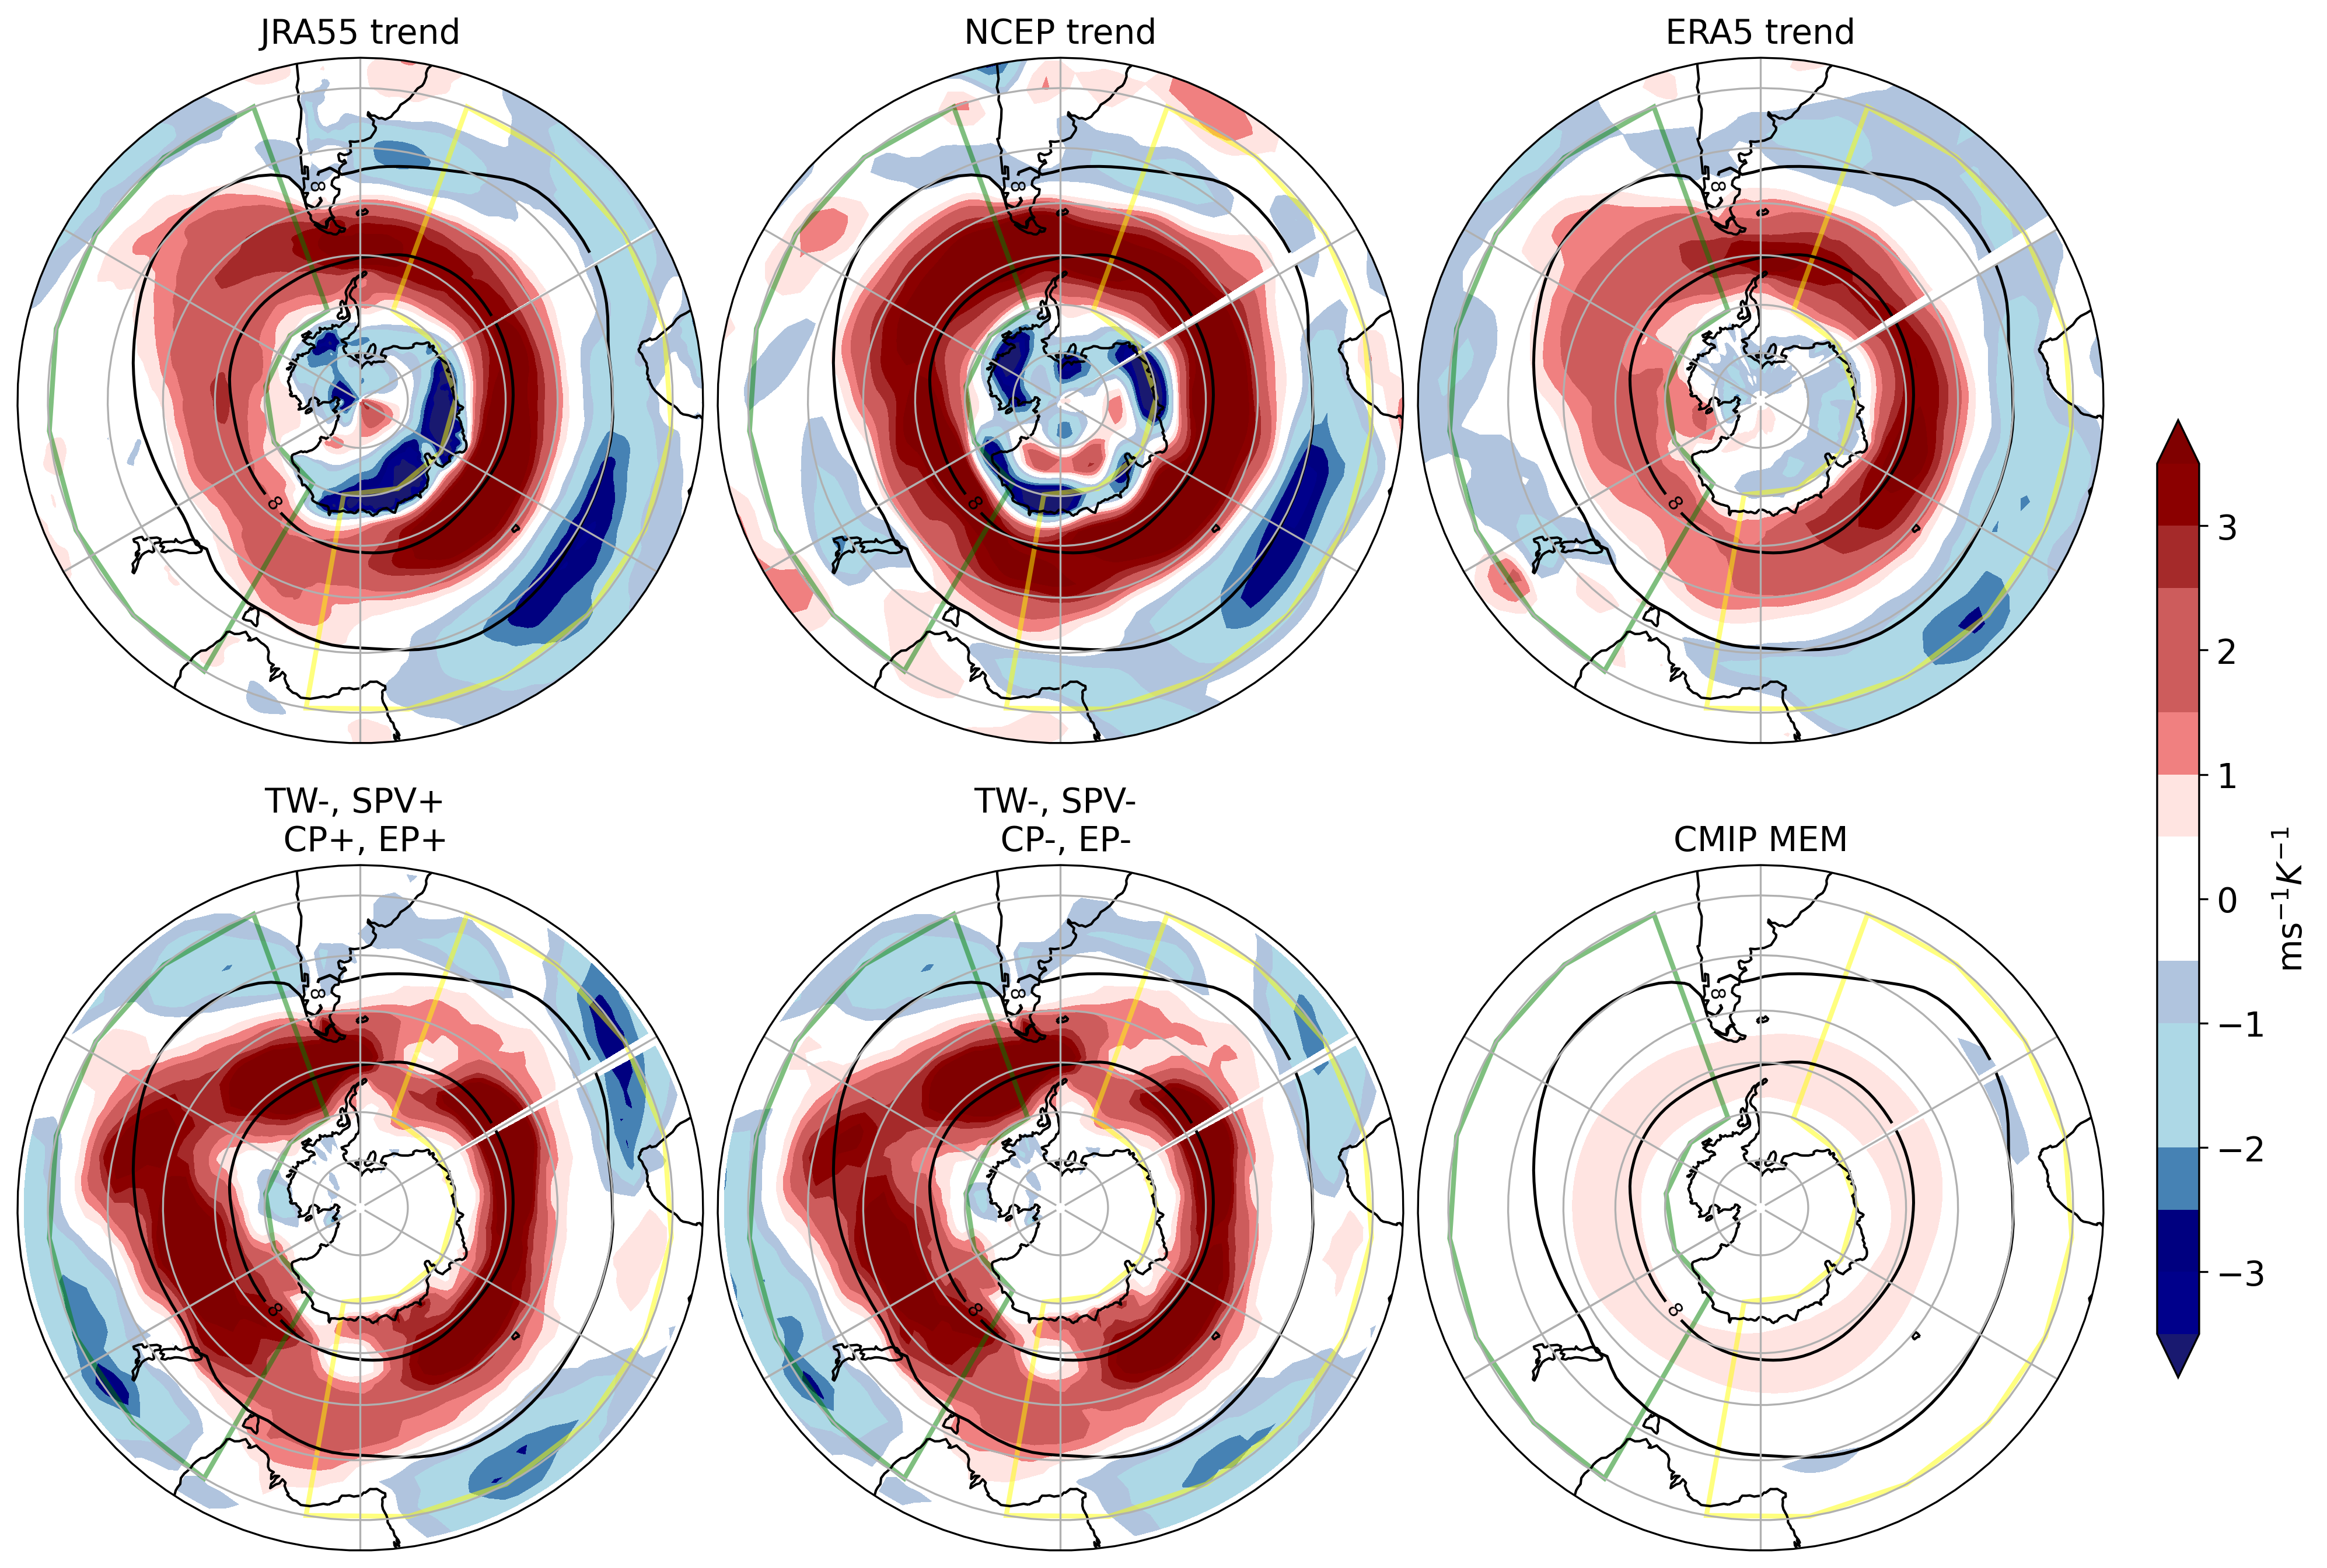

In [90]:
# Titles
titles = ['JRA55 trend',
          'NCEP trend',
          'ERA5 trend',
          'TW-, SPV+ \n CP+, EP+',
          'TW-, SPV- \n CP-, EP-',
          'CMIP MEM']

# trends_sl1, pvalues_sl1 = calculate_trend_and_pvalues(storylines_T42_mem['TW +, SPV +, CP +, EP +'].sel(time=slice('1950','2023')))
# trends_sl2, pvalues_sl2 = calculate_trend_and_pvalues(storylines_T42_mem['TW -, SPV -, CP -, EP -'].sel(time=slice('1950','2023')))
obs_trend = [change_jra55,change_ncep,change_era5,scaled_changes_for_plot[0],scaled_changes_for_plot[1],regression_coefs.MEM]
lat = obs_trend[0].lat
lon = obs_trend[0].lon

# Initialize figure
fig = plt.figure(figsize=(12, 9), dpi=300, constrained_layout=True)
projection = ccrs.SouthPolarStereo(central_longitude=300)
data_crs = ccrs.PlateCarree()

cmapU850 = mpl.colors.ListedColormap(['darkblue','navy','steelblue','lightblue',
                                    'lightsteelblue','white','white','mistyrose',
                                    'lightcoral','indianred','brown','darkred'])
cmapU850.set_over('maroon')
cmapU850.set_under('midnightblue')

# Loop over 4 subplots
for k in range(6):
    # Add cyclic point to avoid blank space at the map edges
    # var_c, lon_c = add_cyclic_point(obs_trend[k], coord=lon)

    # Set up subplot with polar stereographic projection
    ax = plt.subplot(2, 3, k + 1, projection=projection)
    ax.set_extent([0, 359.9, -90,-25], crs=data_crs)

    # Add a circular boundary for a clean polar view
    theta = np.linspace(0, 2 * np.pi, 100)
    center, radius = [0.5, 0.5], 0.5
    verts = np.vstack([np.sin(theta), np.cos(theta)]).T
    circle = mpath.Path(verts * radius + center)
    ax.set_boundary(circle, transform=ax.transAxes)

    # Contour levels and colormap
    if k in [0,1]:
        clevels = np.arange(-3.5, 4, .5)  # Adjust levels for random data
        im1 = ax.contourf(obs_trend[k].lon, obs_trend[k].lat, obs_trend[k], clevels, transform=data_crs, cmap=cmapU850, extend='both')
    else:
        clevels = np.arange(-3.5, 4, .5)  # Adjust levels for random data
        im2 = ax.contourf(obs_trend[k].lon, obs_trend[k].lat, obs_trend[k], clevels, transform=data_crs, cmap=cmapU850, extend='both')    
    cnt=ax.contour(ua_era5_model_grid_T42.lon,ua_era5_model_grid_T42.lat, ua_era5_model_grid_T42.sel(time=slice('1990','2023')).mean(dim='time').values,levels=[8],transform=data_crs,linewidths=1.2, colors='black', linestyles='-')
    plt.clabel(cnt,inline=True,fmt='%1.0f',fontsize=8)
    # Add coastlines and gridlines
    ax.coastlines()
    gl = ax.gridlines(draw_labels=False, dms=True, x_inline=False, y_inline=False)
    gl.xlabel_style = {'size': 10}
    gl.ylabel_style = {'size': 10}

    # Add rectangular boxes for Pacific and Atlantic-Indian basins
    pacific_box = mpatches.Rectangle(
        xy=(-210, -70), width=130, height=40, 
        edgecolor='green', facecolor='none', lw=2, transform=data_crs, alpha=0.5
    )
    atl_ind_box = mpatches.Rectangle(
        xy=(-40, -70), width=170, height=40,
        edgecolor='yellow', facecolor='none', lw=2, transform=data_crs, alpha=0.5
    )
    ax.add_patch(pacific_box)
    ax.add_patch(atl_ind_box)

    # Title for each subplot
    ax.set_title(titles[k], fontsize=14)

# Add a colorbar below the plots
# cbar = fig.colorbar(im, ax=fig.axes, orientation='horizontal', fraction=0.05, pad=0.1)
# cbar.set_label("[m/s/K]", fontsize=14)

plt1_ax = plt.gca()
left, bottom, width, height = plt1_ax.get_position().bounds
colorbar_axes1 = fig.add_axes([left+0.35, bottom, 0.02, height*2])
cbar = fig.colorbar(im1, colorbar_axes1, orientation='vertical')
cbar.set_label(r'ms$^{-1}K^{-1}$', fontsize=14)  #rotation = radianes
cbar.ax.tick_params(axis='both',labelsize=14)


plt.subplots_adjust(bottom=0.2, right=.95, top=0.8)

plt.show()

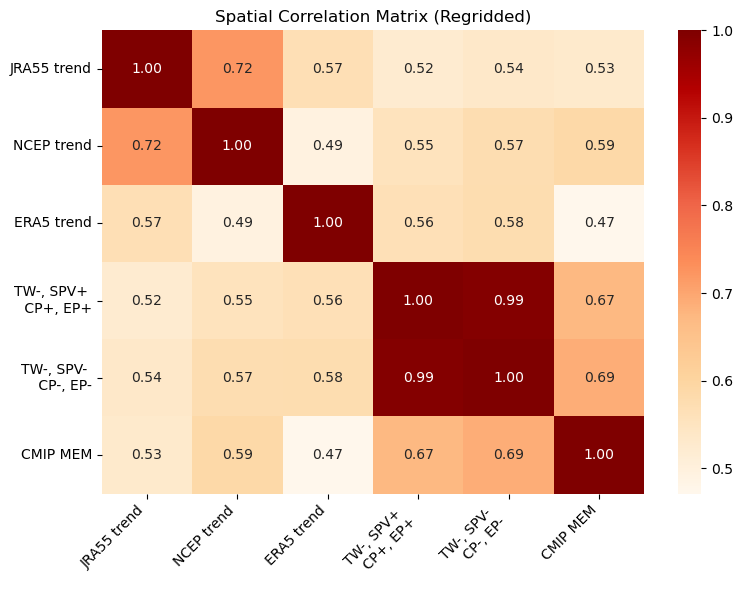

In [91]:
import xarray as xr
import xesmf as xe
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# Define the reference grid (choosing the coarsest resolution)
ref_map = obs_trend[-1]  # Example: use the last dataset as the reference
grid_out = ref_map  # The grid to interpolate all datasets onto

# Function to regrid a dataset
def regrid_data(data, grid_out):
    regridder = xe.Regridder(data, grid_out, method="bilinear", reuse_weights=False)
    return regridder(data)

# Regrid all datasets
obs_trend_regridded = [regrid_data(ds, grid_out) for ds in obs_trend]

# Compute spatial correlation matrix
num_maps = len(obs_trend_regridded)
corr_matrix = np.zeros((num_maps, num_maps))

for i in range(num_maps):
    for j in range(num_maps):
        # Flatten and remove NaNs before correlation
        data1 = obs_trend_regridded[i].values.flatten()
        data2 = obs_trend_regridded[j].values.flatten()
        
        # Mask NaNs
        valid_mask = ~np.isnan(data1) & ~np.isnan(data2)
        if np.sum(valid_mask) > 10:  # Ensure enough valid points
            corr_matrix[i, j], _ = pearsonr(data1[valid_mask], data2[valid_mask])
        else:
            corr_matrix[i, j] = np.nan  # Assign NaN if not enough data

# Create a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="OrRd", xticklabels=titles, yticklabels=titles)
plt.title("Spatial Correlation Matrix (Regridded)")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

